# 1. 芯片初始化操作

In [1]:
import os
import sys
sys.path.append(os.path.dirname(os.getcwd()))
import numpy as np
import time
from pc import PS
from modules import ADC,DAC,CHIP
from command import CMD,CmdData,Packet
from command.singleCmdInfo import *

from util import plot_v_cond,plot_v

In [44]:
chip=CHIP(PS(host="192.168.1.11", port = 7, debug=0),init=True)
chip.set_device_cfg(deviceType=0,IsNew32=True)
chip.adc.set_gap(adc_cs_gap=90,adc_first_gap=200,adc_last_gap=10)
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)
chip.clk_manager.set_cyc(10, 10,delay3=50)
chip.add_compiler("../compiler/code/")

Connected to 192.168.1.11:7
local ip: 192.168.1.15 local port: 50076


In [48]:
chip.adc.set_sample_times(adc_sample_times=1)
chip.generate_read_pulse()

# 2. 读器件

## 2.1 常规读操作

In [ ]:
chip.set_op_mode(read=True,from_row=True)                                   # 设置为读模式, 并且是从行读
chip.set_dac_read_V(0.1,tg=5)                                               # 设置读电压, 会根据device的自动配置对应的DAC通道
chip.set_tia_gain(1)                                                        # 设置TIA的增益
print(chip.get_setting_info())

voltage = chip.read(row_index=[0],col_index=[100],row_value=None,col_value=None,check_tia=True)
print(f"电压:{voltage}v")
cond = chip.voltage_to_cond(voltage=voltage)
print(f"电导:{cond}us")
resistance = chip.voltage_to_resistance(voltage=voltage)
print(f"电阻:{resistance}kΩ")

## 2.2 自定义配置latch读操作

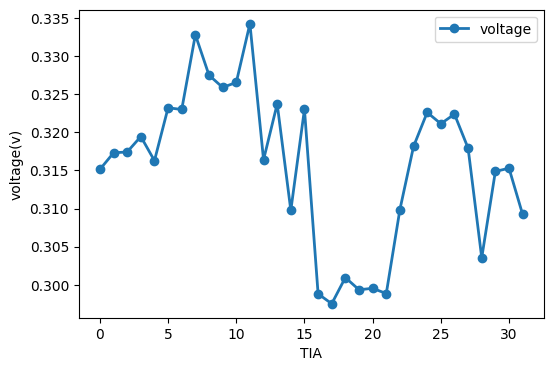

In [47]:
chip.set_op_mode(read=True,from_row=True)
chip.set_dac_read_V(0.1)
chip.set_tia_gain(3)


# 先需要reset所有的latch
chip.set_cim_reset()

# 选任意行配ltach
# # 选任意行bank配32bit值
chip.set_bank([i for i in range(8)],row=True,value=0x11)



# # chip.set_latch([i for i in range(256)],row=False)
chip.set_bank([i for i in range(8)],row=False,value=0xFFFF_FFFF)

# 产生读脉冲, 并读出tia值
chip.generate_read_pulse()
voltage = chip.get_tia_out([k for k in range(32)])
plot_v(v= voltage,figsize=(6,4))
# tia = chip.setting.TIA_index_map(col)
# print(tia)

# plot_v(v= voltage,figsize=(6,4))

In [ ]:
chip.set_op_mode(read=True,from_row=True)
chip.set_dac_read_V(0.1)
chip.set_tia_gain(0)

ans = []
for i in range(1):
    # 先需要reset所有的latch
    chip.set_cim_reset()

    # 选任意行配ltach
    # 选任意行bank配32bit值
    # chip.set_bank([i for i in range(8)],row=True,value=0xFFFF_FFFF)

    # # chip.set_latch([i for i in range(256)],row=False)
    # chip.set_bank([i for i in range(8)],row=False,value=0xFFFF_FFFF)

    # 产生读脉冲, 并读出tia值
    chip.generate_read_pulse()
    voltage = chip.get_tia_out([k for k in range(32)])
    ans.append(voltage)
    plot_v(v= voltage,figsize=(6,4))
    # tia = chip.setting.TIA_index_map(col)
    # print(tia)

    # plot_v(v= voltage,figsize=(6,4))

In [ ]:
tia1 = np.array([0,1,4,5,8,9,12,13,16,17,20,21,24,25,28,29])
tia2 = np.array(tia1)+2
for k,voltage in enumerate(ans):
    for i in tia1:
        # print(voltage[i])
        if voltage[i]<0.35:
            print(k,voltage[i])
    for i in tia2:
        if voltage[i]>0.35:
            print(k,voltage[i])

In [ ]:
tia1 = np.array([16,20])
tia2 = np.array([2,3,6,7,10,11,14,15,18,19,22,23,26,27,30,31])
tia3 = np.array([0,1,4,5,8,9,12,13,17,21,24,25,28,29])
for k,voltage in enumerate(ans):
    for i in tia1:
        # print(voltage[i])
        if voltage[i]<0.35:
            print(k,voltage[i])
    for i in tia2:
        if voltage[i]>0.35:
            print(k,voltage[i])
    for i in tia3:
        if voltage[i]>0.35:
            print(k,voltage[i])

# 3. 写器件

## 3.1 常规写操作

In [ ]:
chip.set_op_mode(read=False,from_row=True)                                  # 设置为写模式, 并且是从行写
chip.set_dac_write_V(5)                                                   # 设置为写模式, 并且是从行写
chip.set_pulse_width(0.1)                                                   # 设置写脉冲宽度
print(chip.get_setting_info())

In [ ]:
chip.write_one(row_index=0,col_index=100)

## 3.2 自定义配置行列写操作

In [ ]:
row = 226
col = 249
tia = chip.setting.TIA_index_map(col,col=True)
print(tia)

In [ ]:
# chip.send_cmd(cmd = [CMD(ADC_FIRST_GAP)],mode=2)
chip.ps.debug=1
pkts=Packet()
pkts.append_single([CMD(ADC_LAST_GAP)],mode=2)
chip.ps.send_packets(pkts,message_check=None)


chip.ps.debug=0
message=chip.ps.receive_packet(4)
print(message.hex())

In [ ]:
need_read=np.zeros((256,256))
need_read[row,col]=1
voltage_point_row = chip.read_point2(crossbar=need_read,read_voltage=0.1,tg=5,gain=2,from_row=True,out_type=0)

cond_sub_base_row = chip.voltage_to_cond(voltage=voltage_point_row)
print(cond_sub_base_row[row,col])

In [ ]:
# chip.generate_read_pulse()
chip.set_op_mode(read=True,from_row=True)                                   # 设置为读模式, 并且是从行读

In [ ]:
chip.ps.debug=1
chip.adc.set_gap(adc_cs_gap=200,adc_first_gap=200,adc_last_gap=200)
chip.ps.debug=0

In [ ]:
chip.set_op_mode(read=True,from_row=True)                                   # 设置为读模式, 并且是从行读
chip.set_dac_read_V(0.1,tg=5)                                               # 设置读电压, 会根据device的自动配置对应的DAC通道
chip.set_tia_gain(1)                                                        # 设置TIA的增益

chip.set_cim_reset()

voltage = chip.read(row_index=[row],col_index=[col],row_value=None,col_value=None,check_tia=True)
print(f"电压:{voltage}v")
cond = chip.voltage_to_cond(voltage=voltage)
print(f"电导:{cond}us")
resistance = chip.voltage_to_resistance(voltage=voltage)
print(f"电阻:{voltage}kΩ")

In [ ]:
chip.set_op_mode(read=False,from_row=True)                                  # 设置为写模式, 并且是从行写
chip.set_dac_write_V(1,tg=5)                                                   # 设置为写模式, 并且是从行写
chip.set_pulse_width(3e-6)   
# 先需要reset所有的latch
chip.set_cim_reset()

# 配置行bank
chip.set_latch([row],row=True,value=None)
# chip.set_bank([i for i in range(8)],row=True,value=0xFFFF_FFFF)

# 配置列bank
chip.set_latch([col],row=False,value=None)
# chip.set_bank([i for i in range(8)],row=False,value=0xFFFF_FFFF)

# 产生写配置
chip.generate_write_pulse()

voltage = chip.get_tia_out([k for k in range(16)])
plot_v(v= voltage,figsize=(6,4))

In [ ]:

tia = chip.setting.TIA_index_map(col,col=False)
print(tia)

# 3. 测试

## 3.1 测试选通对不对

In [ ]:
chip.set_op_mode(read=True,from_row=True)                                   # 设置为读模式, 并且是从行读
chip.set_dac_read_V(0.1,tg=5)                                               # 设置读电压, 会根据device的自动配置对应的DAC通道
chip.adc.set_gain_resistor(big_resistance=10e3,small_resistance=200)        # 设置TIA增益使用的电阻大小
chip.set_tia_gain(1)                                                        # 设置TIA的增益
print(chip.get_setting_info())

In [ ]:
# 0或1 ：串行读写32个寄存器的使能
chip.send_cmd(cmd = [CMD(CIM_EN,command_data=CmdData(1))],mode=1)

In [ ]:
def is_correct_value(voltage,threshold,tia_num):
    for key,value in enumerate(voltage):
        if value>=threshold:
            if key in tia_num:
                pass
            else:
                print(f"这路TIA不应该有值:tia={key},value={value},threshold={threshold}")
                return False
        else:
            if key not in tia_num:
                pass
            else:
                print(f"这路TIA应该有值:tia={key},value={value},threshold={threshold}")
                return False
    return True

In [ ]:
col_bank = 0

chip.send_cmd(cmd = [CMD(SER_PARA_SEL,command_data=CmdData(1))],mode=1)
chip.set_cim_reset()
chip.set_bank([0],row=True,value=0xFFFF_FFFF)
chip.set_bank([col_bank],row=False,value=0x0000_0003)
col_index = chip.setting.bank_to_num([col_bank])

chip.generate_read_pulse()
voltage = chip.get_tia_out([k for k in range(16)])

print(f"第{0}, {1}位设置为1",voltage)
plot_v_cond(voltage,chip.voltage_to_cond(voltage))

for j in range(32):
    chip.send_cmd(cmd = [CMD(SER_PARA_SEL,command_data=CmdData(0))],mode=1)
    chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_reg_clk))],mode=1)          # cfg_reg_clk
    chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_latch_clk))],mode=1)        # cfg_latch_clk

    chip.generate_read_pulse()
    voltage = chip.get_tia_out([k for k in range(16)])
    print(f"第{j}次挤出一位")
    plot_v_cond(voltage,chip.voltage_to_cond(voltage))
    if j == 31:
        print(is_correct_value(voltage,0.1,tia_num=[]))
    else:
        col1,col2= col_index[min(31,j+1)],col_index[min(31,j+2)]
        tia = [chip.setting.TIA_index_map(col1),chip.setting.TIA_index_map(col2)]
        print(is_correct_value(voltage,0.1,tia_num=tia))

## 3.2 电阻板测试

In [3]:
# # 电阻版测试需要配置最后一个DAC的通道电压
# v=0
# chip.clear_dac_v()
chip.dac.set_voltage(1,dac_num=0,dac_channel=0)             # ROW_Va电压
chip.dac.set_voltage(1,dac_num=0,dac_channel=1)             # ROW_Va电压
chip.dac.set_voltage(1,dac_num=0,dac_channel=2)             # ROW_Va电压
chip.dac.set_voltage(1,dac_num=0,dac_channel=3)             # ROW_Va电压

chip.dac.set_voltage(1,dac_num=0,dac_channel=4)             # COL_Va电压
chip.dac.set_voltage(1,dac_num=0,dac_channel=5)             # COL_Va电压
chip.dac.set_voltage(1,dac_num=0,dac_channel=6)             # COL_Va电压
chip.dac.set_voltage(1,dac_num=0,dac_channel=7)             # COL_Va电压

chip.dac.set_voltage(1,dac_num=1,dac_channel=0)             # ROW_Vc
chip.dac.set_voltage(1,dac_num=1,dac_channel=1)             # COL_Vc     
chip.dac.set_voltage(1,dac_num=1,dac_channel=2)             # GL
chip.dac.set_voltage(1,dac_num=1,dac_channel=3)             # GR

chip.dac.set_voltage(1,dac_num=1,dac_channel=4)             # ROW_Vc
chip.dac.set_voltage(1,dac_num=1,dac_channel=5)             # COL_Vc     
chip.dac.set_voltage(1,dac_num=1,dac_channel=6)             # GL
chip.dac.set_voltage(1,dac_num=1,dac_channel=7)             # GR

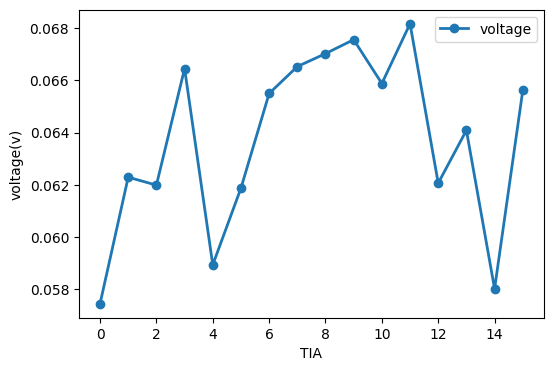

In [4]:
chip.set_op_mode(read=True,from_row=False)
chip.set_tia_gain(0)
chip.set_cim_reset()
chip.generate_read_pulse()
voltage = chip.get_tia_out([k for k in range(16)])
plot_v(v= voltage,figsize=(6,4))

## 3.3 指令测试

In [ ]:
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_latch_clk))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_reg_clk))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_SS,command_data=CmdData(0))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_SS,command_data=CmdData(1))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_SS,command_data=CmdData(0))],mode=1)

chip.send_cmd(cmd = [CMD(CIM_DATA_IN,command_data=CmdData(0xFFFF_FFFF))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_cim_data_in))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_DATA_IN,command_data=CmdData(0))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_cim_data_in))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_DATA_IN,command_data=CmdData(0xFFFF))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_cim_data_in))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_DATA_IN,command_data=CmdData(0))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_cim_data_in))],mode=1)

chip.send_cmd(cmd = [CMD(CIM_BANK_SEL,command_data=CmdData(0xFF))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_bank_sel))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_BANK_SEL,command_data=CmdData(0x0))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_bank_sel))],mode=1)

In [ ]:
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_latch_clk))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_SS,command_data=CmdData(0))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_SS,command_data=CmdData(1))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_SS,command_data=CmdData(0))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_DATA_IN,command_data=CmdData(0xFFFF_FFFF))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_cim_data_in))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_DATA_IN,command_data=CmdData(0))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_cim_data_in))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_DATA_IN,command_data=CmdData(0xFFFF))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_cim_data_in))],mode=1)
chip.send_cmd(cmd = [CMD(CIM_DATA_IN,command_data=CmdData(0))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_cim_data_in))],mode=1)

chip.send_cmd(cmd = [CMD(CIM_DATA_IN,command_data=CmdData(0))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_cim_data_in))],mode=1)

chip.send_cmd(cmd = [CMD(CIM_DATA_IN,command_data=CmdData(0xFFFF_FFFF))],mode=1)
chip.send_cmd(cmd = [CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_cim_data_in))],mode=1)


pkts=Packet()
pkts.append_cmdlist([
    # 行reg配置
    CMD(CIM_SS,command_data=CmdData(0)),
    CMD(CIM_RESET,command_data=CmdData(0)),
    CMD(CIM_DATA_IN,command_data=CmdData(0XFf)),                                       # 第xindex位置1
    CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_cim_data_in)),       # cfg_cim_data_in
    
    CMD(CIM_SS,command_data=CmdData(1)),
    CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_reg_clk)),           # cfg_reg_clk
    # 行bank配置
    CMD(CIM_RESET,command_data=CmdData(1)),

    CMD(ROW_COL_SEL,command_data=CmdData(1)),                                 # 设置为行/列模式
    CMD(CIM_BANK_SEL,command_data=CmdData(0xFF)),                                        # bank选择
    CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_bank_sel)),          # cfg_bank_sel
    CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_latch_clk)),         # cfg_latch_clk

    CMD(ROW_COL_SEL,command_data=CmdData(0)),                                 # 设置为行/列模式
    CMD(CIM_BANK_SEL,command_data=CmdData(0xF)),                                        # bank选择
    CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_bank_sel)),          # cfg_bank_sel
    CMD(FAST_COMMAND_1,command_data=CmdData(FAST_COMMAND1_CONF.cfg_latch_clk)),         # cfg_latch_clk
],mode=1)   
chip.ps.send_packets(pkts)